<a href="https://colab.research.google.com/github/aryanranga721-ops/Week2_Aryan/blob/main/Week2_Aryan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Global Imports & Environment Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import os
import kagglehub

# Suppress warnings
warnings.filterwarnings('ignore')

# Presentation Plotting Configurations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
print("Global environment and libraries successfully initialized.")

Global environment and libraries successfully initialized.


## Loading Dataset from kegglehub to colab

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tesla-ea-deliveries-and-production-data20152025' dataset.
Path to dataset files: /kaggle/input/tesla-ea-deliveries-and-production-data20152025


In [3]:
import os
os.listdir('/kaggle/input/tesla-ea-deliveries-and-production-data20152025')

['tesla_deliveries_dataset_2015_2025.csv']

In [4]:
csv_path = '/kaggle/input/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv'
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

print(f"\nDataset successfully initialized. Global dimensions: {df.shape}")


Dataset successfully initialized. Global dimensions: (2640, 12)


## Initial Data Profiling & Quality Checks

1. Data Structural Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


2. Missing Value Distribution

In [6]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


3. Processing Duplications

In [7]:
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(df)} duplicate rows.")

Removed 0 duplicate rows.


In [9]:
df.dropna()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


4. Target Data Types Preview

In [10]:
print(df.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


## **Exploratory Data Analysis (EDA) - Visualizations**

1. Distribution of Average Car Selling Prices

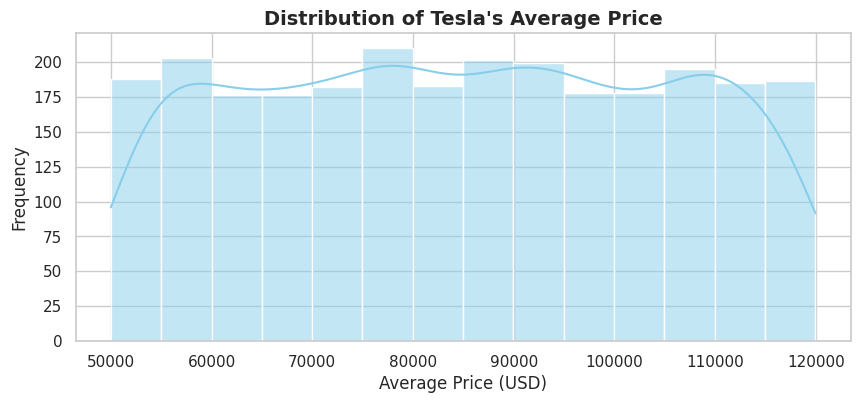

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Avg_Price_USD'], kde=True, color='skyblue')
plt.title("Distribution of Tesla's Average Price", fontweight='bold')
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")
plt.show()

2. Production Volume Evolution Over Time by Vehicle Model Type

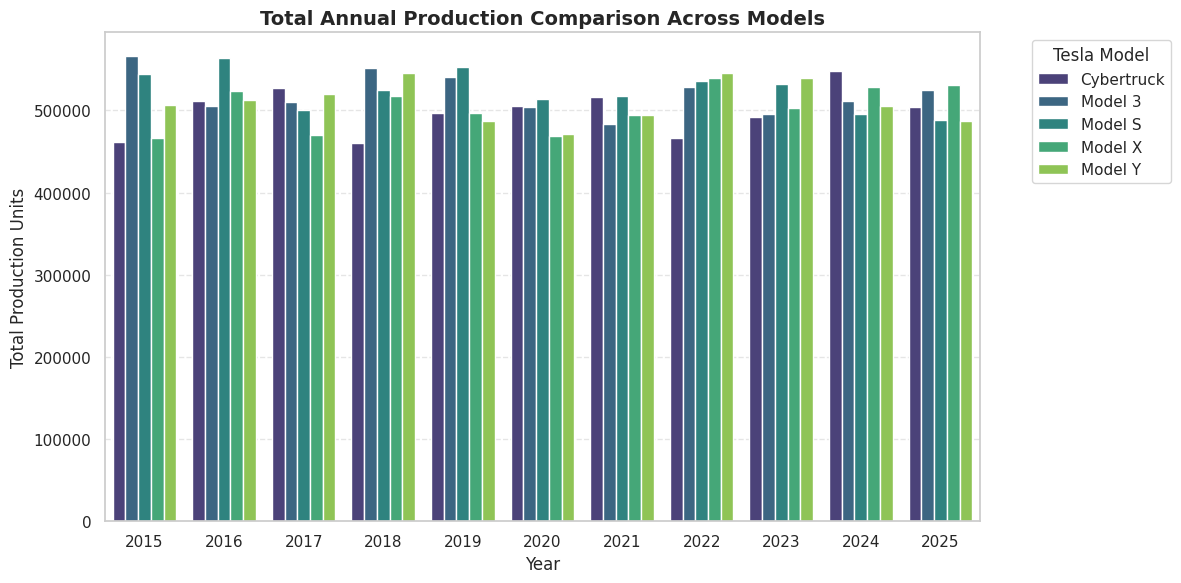

In [12]:
annual_df = df.groupby(['Year', 'Model'])['Production_Units'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=annual_df, x='Year', y='Production_Units', hue='Model', palette='viridis')
plt.title('Total Annual Production Comparison Across Models', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Production Units')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tesla Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

3. Numeric Correlation Evaluation Matrix Heatmap

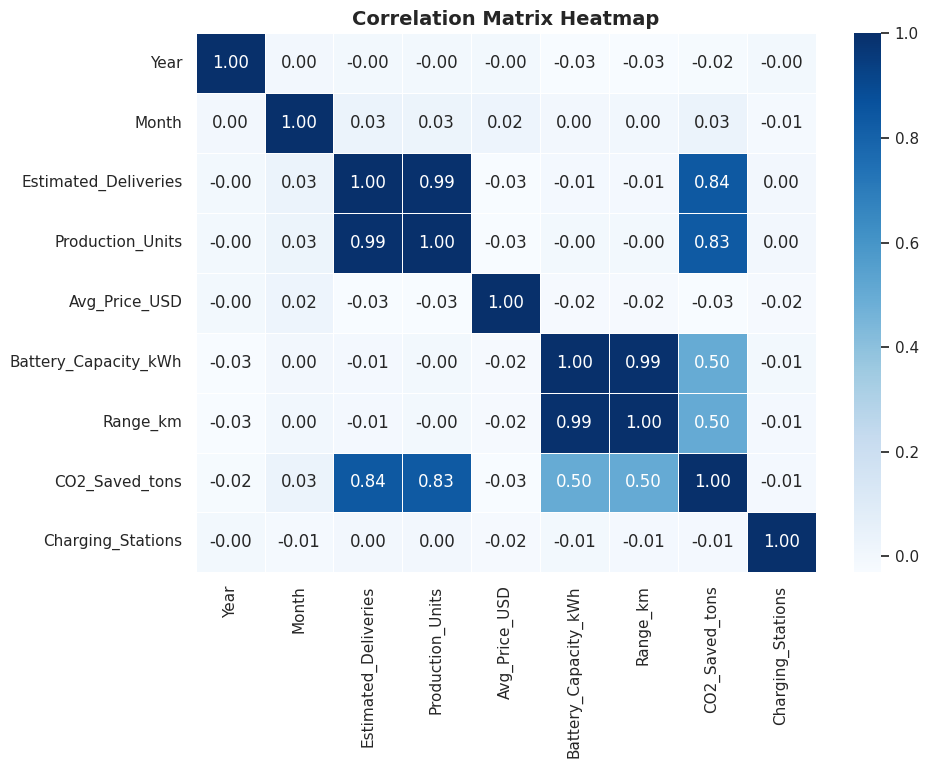

In [13]:
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=14, fontweight="bold")
plt.show()

## **Time Series Aggregation & Clean Timeline Construction**

In [14]:
# Construct an explicit timestamp representation using Year and Month
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

# Aggregate regional segments into clean global monthly timelines
df_ts = df.groupby('Date').agg({
    'Estimated_Deliveries': 'sum',
    'Production_Units': 'sum',
    'Avg_Price_USD': 'mean',
    'Battery_Capacity_kWh': 'mean',
    'Range_km': 'mean'
}).sort_index()

print("Pipeline Data Framework Ready. Clean Monthly Series Shape:", df_ts.shape)
print(df_ts.head(4))

Pipeline Data Framework Ready. Clean Monthly Series Shape: (132, 5)
            Estimated_Deliveries  Production_Units  Avg_Price_USD  \
Date                                                                
2015-01-01                183180            195793     84502.4970   
2015-02-01                165053            176119     81745.5695   
2015-03-01                184567            200151     86221.2895   
2015-04-01                225623            241706     83446.1640   

            Battery_Capacity_kWh  Range_km  
Date                                        
2015-01-01                 85.45    491.35  
2015-02-01                 85.25    494.55  
2015-03-01                 84.75    490.35  
2015-04-01                 92.35    527.95  


##**Feature Engineering & Eliminating Target Leakage**

In [15]:
df_features = df_ts.copy()

# 1. THE CORE FIX: Predict the Month-over-Month CHANGE instead of raw absolute values
df_features['Deliveries_Change'] = df_features['Estimated_Deliveries'].diff()

# 2. Capture Seasonal Context Features
df_features['Month_Factor'] = df_features.index.month

# 3. Store the actual previous month's value as a baseline feature for reconstruction
df_features['Actual_Deliveries_Lag_1'] = df_features['Estimated_Deliveries'].shift(1)

# 4. ELIMINATE TARGET LEAKAGE: Shift operational metrics backward by 1 month
df_features['Production_Lag_1'] = df_features['Production_Units'].shift(1)
df_features['Price_Lag_1'] = df_features['Avg_Price_USD'].shift(1)

# 5. Build Historical Change Lags (Short-term memory & 12-Month Annual Seasonal Change)
df_features['Change_Lag_1'] = df_features['Deliveries_Change'].shift(1)
df_features['Change_Lag_2'] = df_features['Deliveries_Change'].shift(2)
df_features['Change_Lag_12'] = df_features['Deliveries_Change'].shift(12)

# Clear out raw current-month indicators to maintain a clean forecasting logic
df_features.drop(columns=['Production_Units', 'Avg_Price_USD'], errors='ignore', inplace=True)

# Drop rows containing initial empty values from the diff/shift steps
df_features.dropna(inplace=True)

print("Feature matrix successfully optimized using stationary target differencing.")
print(df_features[['Estimated_Deliveries', 'Deliveries_Change', 'Actual_Deliveries_Lag_1']].head(3))

Feature matrix successfully optimized using stationary target differencing.
            Estimated_Deliveries  Deliveries_Change  Actual_Deliveries_Lag_1
Date                                                                        
2016-02-01                218600            27531.0                 191069.0
2016-03-01                191208           -27392.0                 218600.0
2016-04-01                184134            -7074.0                 191208.0


## **Chronological Train-Test Horizon Splitting**

In [16]:
# Separate features (X) from our target variable (y)
X = df_features.drop(columns=['Estimated_Deliveries'])
y = df_features['Estimated_Deliveries']

# Allocate exactly the last 12 chronological records for validation
test_horizon = 12
X_train, X_test = X.iloc[:-test_horizon], X.iloc[-test_horizon:]
y_train, y_test = y.iloc[:-test_horizon], y.iloc[-test_horizon:]

print("Data Chronologically Segmented:")
print(f"Training Window: {X_train.index.min().strftime('%Y-%m')} to {X_train.index.max().strftime('%Y-%m')} ({len(X_train)} months)")
print(f"Testing Horizon: {X_test.index.min().strftime('%Y-%m')} to {X_test.index.max().strftime('%Y-%m')} ({len(X_test)} months)")

Data Chronologically Segmented:
Training Window: 2016-02 to 2024-12 (107 months)
Testing Horizon: 2025-01 to 2025-12 (12 months)


## **Machine Learning Track - Hyperparameter Tuning**

In [17]:
gb_model = GradientBoostingRegressor(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=tscv,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("\nOptimizing Gradient Boosting Regressor Parameters...")
gb_search.fit(X_train, y_train)
best_gb = gb_search.best_estimator_
print(f"Optimal Tuning Parameters Identified: {gb_search.best_params_}")

# Align model prediction output with evaluation tracking variable
y_pred_ml = best_gb.predict(X_test)


Optimizing Gradient Boosting Regressor Parameters...
Optimal Tuning Parameters Identified: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.05}


##**Statistical Track - Holt-Winters Modeling**

In [18]:
ts_baseline = ExponentialSmoothing(y_train, seasonal_periods=12, trend='add', seasonal='add')
ts_fitted = ts_baseline.fit()

# Generate projections for the 12-month test horizon
y_pred_stat = ts_fitted.forecast(steps=test_horizon)

print("Statistical timeline model successfully calculated and fitted.")

Statistical timeline model successfully calculated and fitted.


##**Performance Scoreboard & Presentation Evaluation Dashboard**


========================= PIPELINE PERFORMANCE SCOREBOARD =========================
                     Model Strategy     RMSE     MAE  R² Score
Tuned Random Forest (True Forecast)  4820.63 3780.79      0.86
         Holt-Winters Baseline (TS) 11907.90 9570.38      0.14



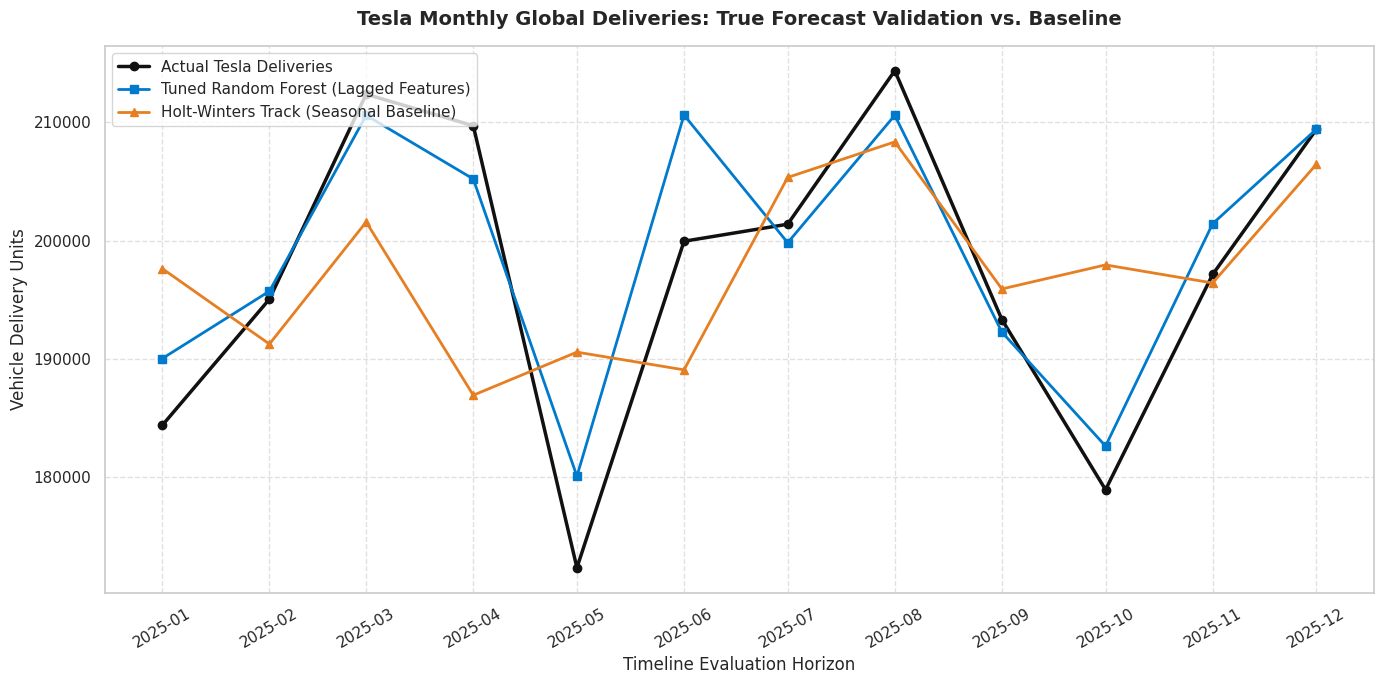

In [19]:
# Summary metrics generator function
def calculate_metrics(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Model Strategy': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R² Score': round(r2, 2)}

# Formulate summary output frame
metrics_summary = pd.DataFrame([
    calculate_metrics(y_true=y_test, y_pred=y_pred_ml, name='Tuned Random Forest (True Forecast)'),
    calculate_metrics(y_test, y_pred_stat, 'Holt-Winters Baseline (TS)')
])

print("\n" + "="*25 + " PIPELINE PERFORMANCE SCOREBOARD " + "="*25)
print(metrics_summary.to_string(index=False))
print("="*75 + "\n")

# ---- Generate Comparative Presentation Line Chart ----
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Tesla Deliveries', color='#111111', linewidth=2.5, marker='o')
plt.plot(y_test.index, y_pred_ml, label='Tuned Random Forest (Lagged Features)', color='#007acc', linestyle='-', marker='s', linewidth=2)
plt.plot(y_test.index, y_pred_stat.values, label='Holt-Winters Track (Seasonal Baseline)', color='#e67e22', linestyle='-', marker='^', linewidth=2)

plt.title('Tesla Monthly Global Deliveries: True Forecast Validation vs. Baseline', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline Evaluation Horizon', fontsize=12)
plt.ylabel('Vehicle Delivery Units', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

# Format x-axis tags to read cleanly as Year-Month labels
plt.xticks(y_test.index, [d.strftime('%Y-%m') for d in y_test.index], rotation=30)
plt.tight_layout()
plt.show()